<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-07-20 23:35:52--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 198.23.119.245
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|198.23.119.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  39.2MB/s    in 4.0s    

2026-07-20 23:35:56 (37.7 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



In [7]:
##Write your code here
df_plot = (
    df[["Age", "JobSatPoints_6", "JobSatPoints_7"]]
    .dropna()
    .copy()
)

median_job_sat = (
    df_plot
    .groupby("Age")[["JobSatPoints_6", "JobSatPoints_7"]]
    .median()
    .sort_index()
)

print(median_job_sat)

                    JobSatPoints_6  JobSatPoints_7
Age                                               
18-24 years old               15.0            20.0
25-34 years old               20.0            15.0
35-44 years old               20.0            15.0
45-54 years old               20.0            15.0
55-64 years old               20.0            20.0
65 years or older             20.0            15.0
Prefer not to say             10.0             7.0
Under 18 years old             1.5             5.0


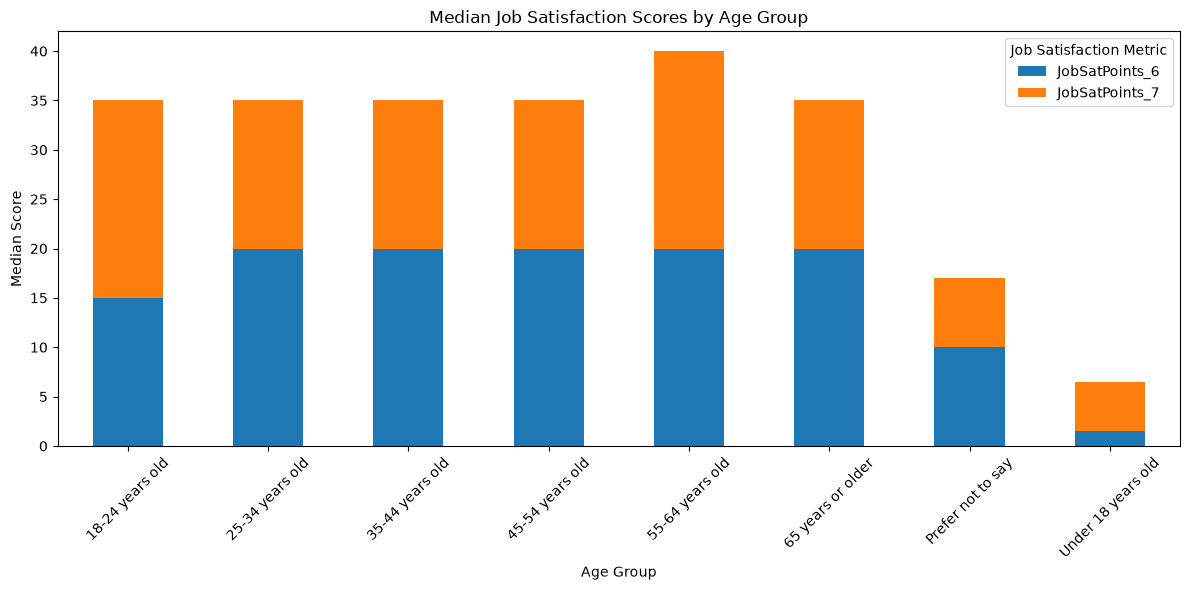

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

median_job_sat.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Median Job Satisfaction Scores by Age Group"
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Median Score")
ax.legend(title="Job Satisfaction Metric")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


In [9]:
##Write your code here

df_plot = (
    df[["Employment", "JobSatPoints_6", "JobSatPoints_7"]]
    .dropna()
    .copy()
)

df_plot["Employment"] = (
    df_plot["Employment"]
    .str.split(";")
)

df_plot = df_plot.explode("Employment")

df_plot["Employment"] = (
    df_plot["Employment"]
    .str.strip()
)

df_plot = df_plot[
    df_plot["Employment"].ne("")
].copy()

median_job_sat_employment = (
    df_plot
    .groupby("Employment")[["JobSatPoints_6", "JobSatPoints_7"]]
    .median()
    .sort_values(
        by=["JobSatPoints_6", "JobSatPoints_7"],
        ascending=False
    )
)

print(median_job_sat_employment)

                                                    JobSatPoints_6  \
Employment                                                           
Employed, full-time                                           20.0   
Student, part-time                                            15.0   
Employed, part-time                                           15.0   
Independent contractor, freelancer, or self-emp...            15.0   
Student, full-time                                            10.0   
Retired                                                       10.0   
Not employed, and not looking for work                        10.0   
Not employed, but looking for work                            10.0   

                                                    JobSatPoints_7  
Employment                                                          
Employed, full-time                                           15.0  
Student, part-time                                            20.0  
Employed, part-time    

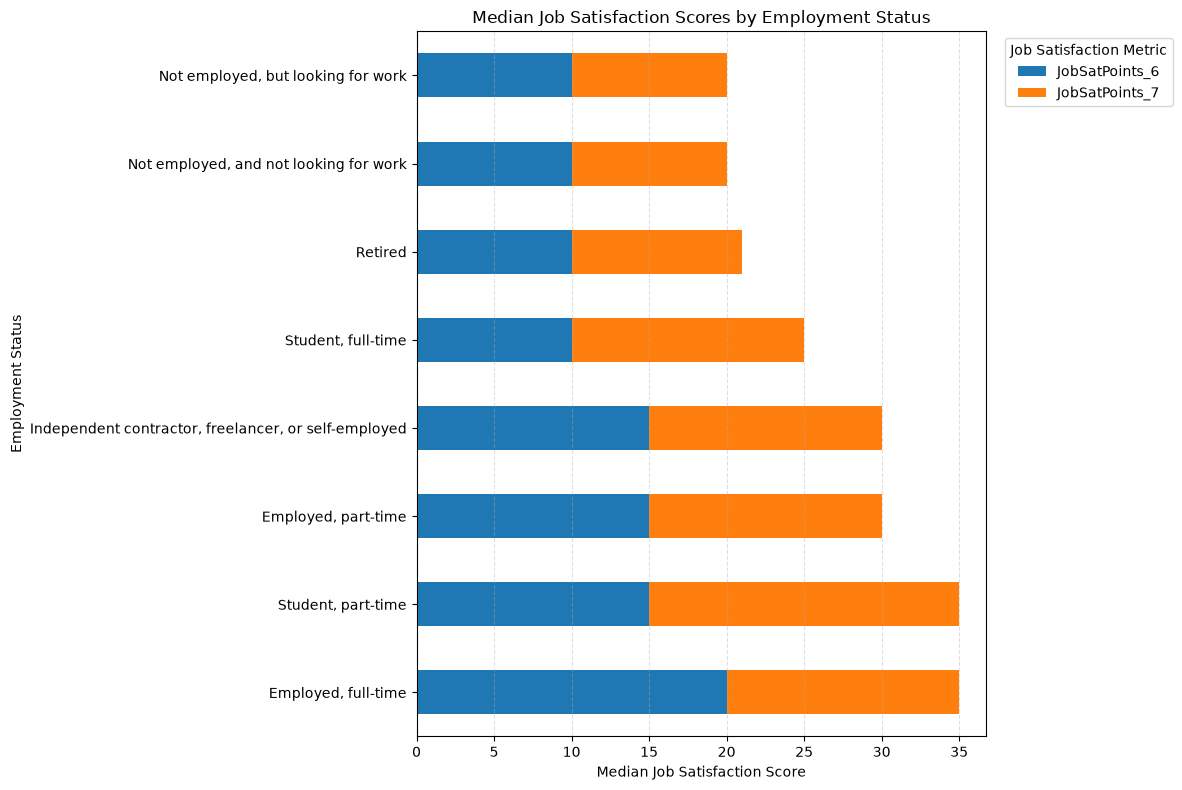

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))

median_job_sat_employment.plot(
    kind="barh",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Median Job Satisfaction Scores by Employment Status"
)

ax.set_xlabel("Median Job Satisfaction Score")
ax.set_ylabel("Employment Status")
ax.legend(
    title="Job Satisfaction Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


In [15]:
df["Age"].value_counts().sort_index()

Age
18-24 years old       14098
25-34 years old       23911
35-44 years old       14942
45-54 years old        6249
55-64 years old        2575
65 years or older       772
Prefer not to say       322
Under 18 years old     2568
Name: count, dtype: int64

In [16]:
##Write your code here
df_plot = (
    df[["Age", "ConvertedCompYearly", "JobSatPoints_6"]]
    .dropna()
    .copy()
)

df_plot = df_plot[
    df_plot["Age"] == "25-34 years old"
]

summary = (
    df_plot[["ConvertedCompYearly", "JobSatPoints_6"]]
    .median()
    .to_frame(name="Median")
)

print(summary)

                      Median
ConvertedCompYearly  59872.0
JobSatPoints_6          20.0


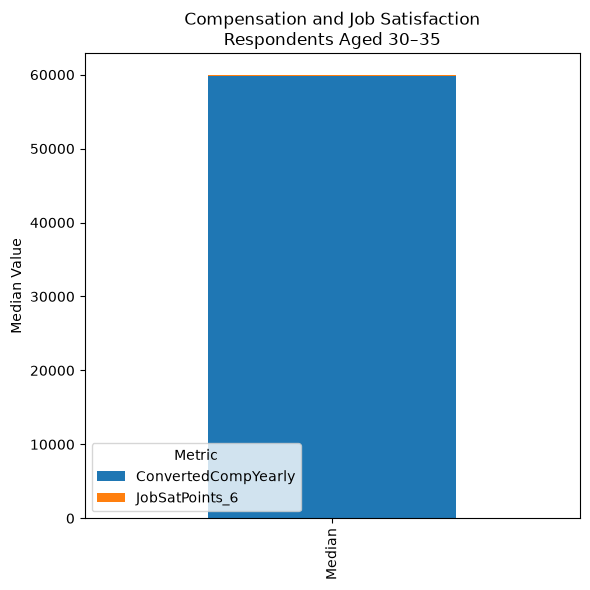

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))

summary.T.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Compensation and Job Satisfaction\nRespondents Aged 30–35"
)

ax.set_ylabel("Median Value")
ax.legend(title="Metric")

plt.tight_layout()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


In [18]:
##Write your code here
df_plot = (
    df[["Age", "ConvertedCompYearly", "JobSatPoints_6"]]
    .dropna()
    .copy()
)

summary = (
    df_plot
    .groupby("Age")[["ConvertedCompYearly", "JobSatPoints_6"]]
    .median()
    .sort_index()
)

print(summary)

                    ConvertedCompYearly  JobSatPoints_6
Age                                                    
18-24 years old                 25735.0            20.0
25-34 years old                 59872.0            20.0
35-44 years old                 85925.0            20.0
45-54 years old                100900.5            20.0
55-64 years old                119189.5            20.0
65 years or older              121668.0            20.0
Prefer not to say              133023.5            15.0
Under 18 years old               8661.0            10.0


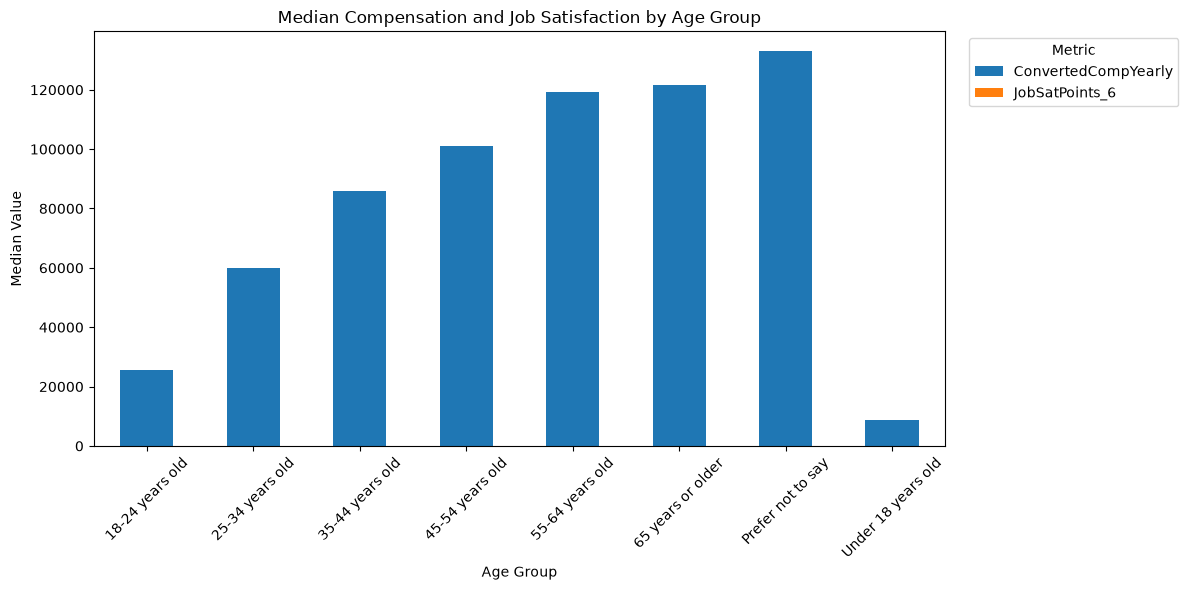

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

summary.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "Median Compensation and Job Satisfaction by Age Group"
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Median Value")

ax.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


In [36]:
##Write your code here
df_plot = (
    df[["Age", "DatabaseWantToWorkWith"]]
    .dropna()
    .copy()
)

df_plot["DatabaseWantToWorkWith"] = (
    df_plot["DatabaseWantToWorkWith"]
    .str.split(";")
)

df_plot = (
    df_plot
    .explode("DatabaseWantToWorkWith")
    .reset_index(drop=True)
)

df_plot["DatabaseWantToWorkWith"] = (
    df_plot["DatabaseWantToWorkWith"]
    .str.strip()
)

df_plot = (
    df_plot[
        df_plot["DatabaseWantToWorkWith"].ne("")
    ]
    .copy()
)

In [37]:
top_databases = (
    df_plot["DatabaseWantToWorkWith"]
    .value_counts()
    .head(5)
    .index
)

df_plot = (
    df_plot[
        df_plot["DatabaseWantToWorkWith"].isin(top_databases)
    ]
    .copy()
)

In [38]:
database_age_counts = pd.crosstab(
    index=df_plot["Age"],
    columns=df_plot["DatabaseWantToWorkWith"]
)

database_age_proportions = (
    database_age_counts
    .div(database_age_counts.sum(axis=1), axis=0)
)

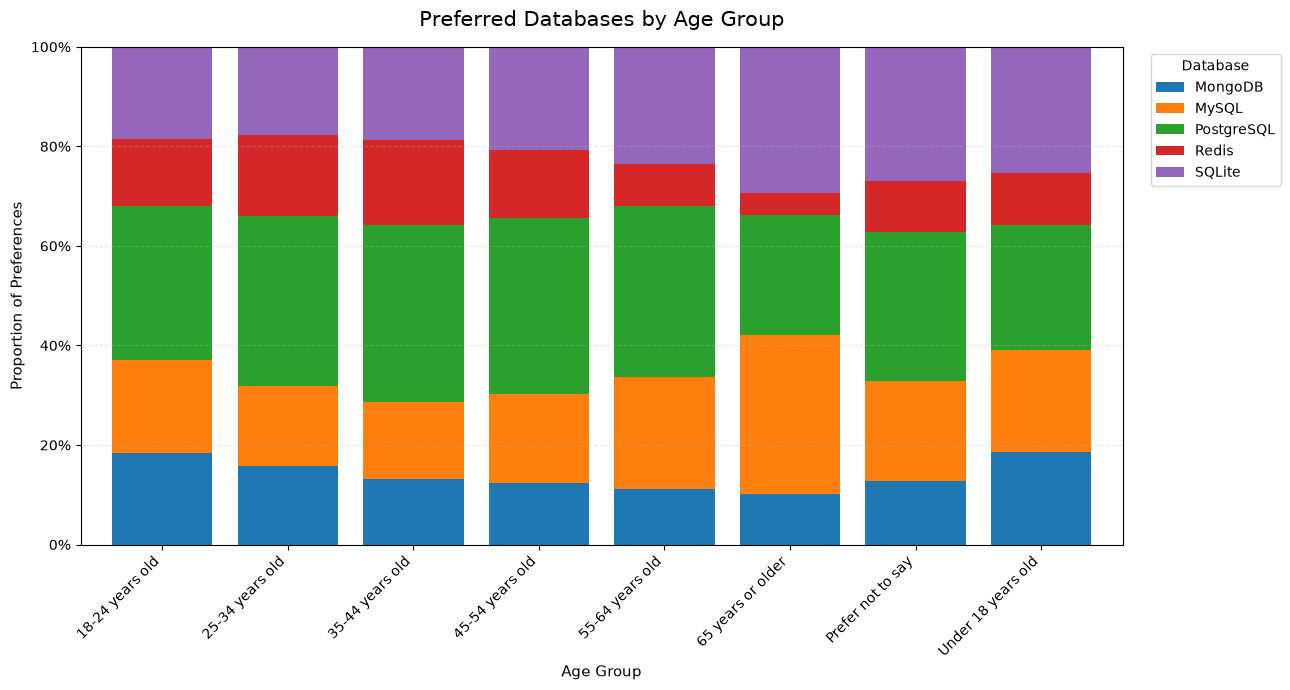

In [40]:
fig, ax = plt.subplots(figsize=(13, 7))

database_age_proportions.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8
)

ax.set_title(
    "Preferred Databases by Age Group",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Age Group", fontsize=11)
ax.set_ylabel("Proportion of Preferences", fontsize=11)

# Mostrar el eje Y como porcentaje
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

# Cada barra representa el 100 %
ax.set_ylim(0, 1)

ax.legend(
    title="Database",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


In [41]:
##Write your code here
df_plot = (
    df[["JobSat", "Employment"]]
    .dropna()
    .copy()
)

df_plot["Employment"] = (
    df_plot["Employment"]
    .str.split(";")
)

df_plot = (
    df_plot
    .explode("Employment")
    .reset_index(drop=True)
)

df_plot["Employment"] = (
    df_plot["Employment"]
    .str.strip()
)

df_plot = (
    df_plot[
        df_plot["Employment"].ne("")
    ]
    .copy()
)

In [42]:
top_employment_types = (
    df_plot["Employment"]
    .value_counts()
    .head(5)
    .index
)

df_plot = (
    df_plot[
        df_plot["Employment"].isin(top_employment_types)
    ]
    .copy()
)

In [43]:
employment_job_sat_counts = pd.crosstab(
    index=df_plot["JobSat"],
    columns=df_plot["Employment"]
)
employment_job_sat_proportions = (
    employment_job_sat_counts
    .div(employment_job_sat_counts.sum(axis=1), axis=0)
)
display(employment_job_sat_proportions)

print(employment_job_sat_proportions.sum(axis=1))

Employment,"Employed, full-time","Employed, part-time","Independent contractor, freelancer, or self-employed","Student, full-time","Student, part-time"
JobSat,,,,,
0.0,0.770492,0.051913,0.109290,0.019126,0.049180
1.0,0.736364,0.084848,0.112121,0.030303,0.036364
2.0,0.754615,0.058632,0.110749,0.028230,0.047774
3.0,0.757796,0.060914,0.104423,0.037708,0.039159
4.0,0.741341,0.064112,0.123066,0.032424,0.039057
5.0,0.767553,0.058439,0.117314,0.028783,0.027911
6.0,0.768867,0.056319,0.110160,0.033566,0.031088
7.0,0.777838,0.052305,0.114991,0.031275,0.023591
8.0,0.769782,0.049568,0.125171,0.028877,0.026603


JobSat
0.0     1.0
1.0     1.0
2.0     1.0
3.0     1.0
4.0     1.0
5.0     1.0
6.0     1.0
7.0     1.0
8.0     1.0
9.0     1.0
10.0    1.0
dtype: float64


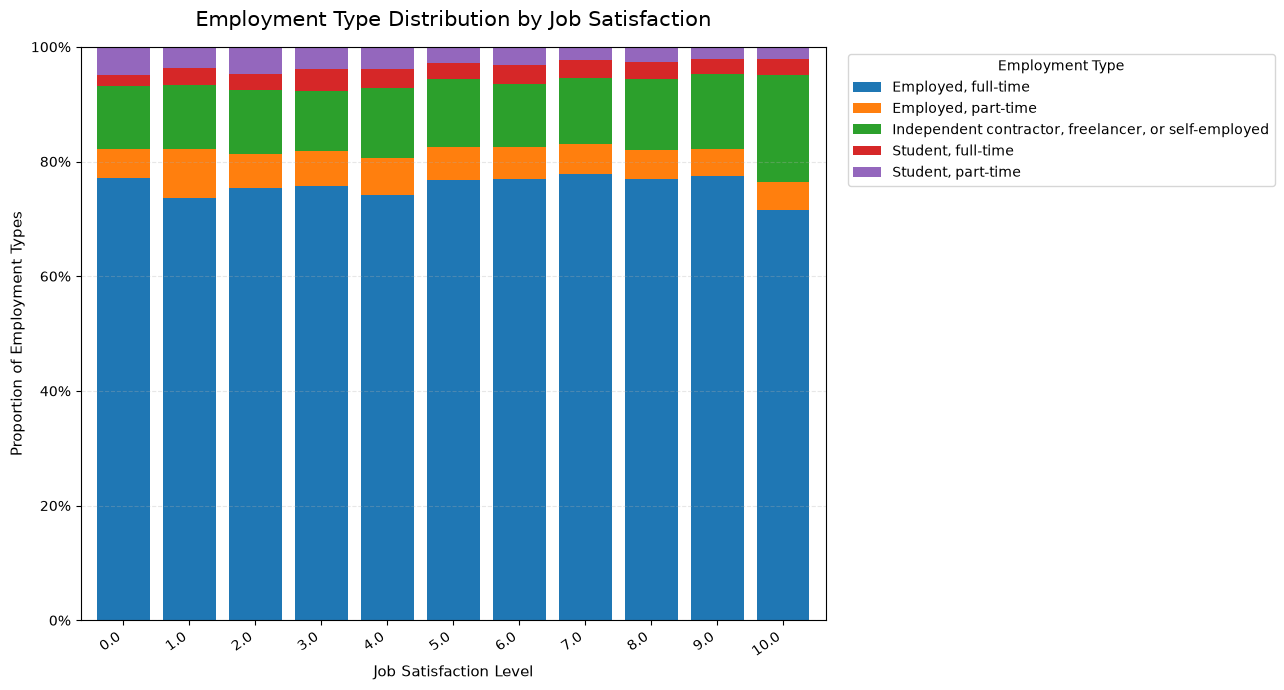

In [44]:
fig, ax = plt.subplots(figsize=(13, 7))

employment_job_sat_proportions.plot(
    kind="bar",
    stacked=True,
    width=0.8,
    ax=ax
)

ax.set_title(
    "Employment Type Distribution by Job Satisfaction",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Job Satisfaction Level", fontsize=11)
ax.set_ylabel("Proportion of Employment Types", fontsize=11)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.set_ylim(0, 1)

ax.legend(
    title="Employment Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


In [45]:
##Write your code here
df_plot = (
    df[["Age", "LanguageAdmired"]]
    .dropna()
    .copy()
)

df_plot["LanguageAdmired"] = (
    df_plot["LanguageAdmired"]
    .str.split(";")
)

df_plot = (
    df_plot
    .explode("LanguageAdmired")
    .reset_index(drop=True)
)

df_plot["LanguageAdmired"] = (
    df_plot["LanguageAdmired"]
    .str.strip()
)

df_plot = (
    df_plot[
        df_plot["LanguageAdmired"].ne("")
    ]
    .copy()
)

In [46]:
top_languages = (
    df_plot["LanguageAdmired"]
    .value_counts()
    .head(5)
    .index
)

df_plot = (
    df_plot[
        df_plot["LanguageAdmired"].isin(top_languages)
    ]
    .copy()
)

In [47]:
language_age_counts = pd.crosstab(
    index=df_plot["Age"],
    columns=df_plot["LanguageAdmired"]
)

language_age_proportions = (
    language_age_counts
    .div(language_age_counts.sum(axis=1), axis=0)
)

In [48]:
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
    "Prefer not to say"
]

language_age_proportions = (
    language_age_proportions
    .reindex(age_order)
    .dropna(how="all")
)

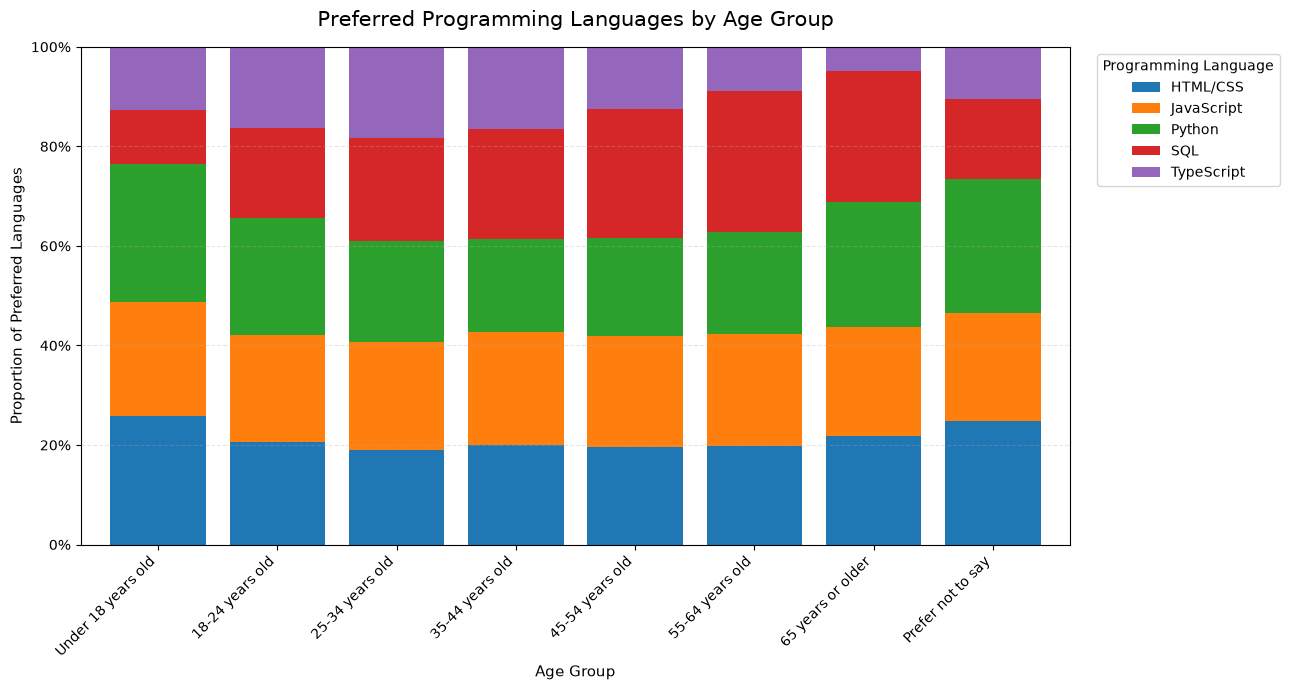

In [49]:
fig, ax = plt.subplots(figsize=(13, 7))

language_age_proportions.plot(
    kind="bar",
    stacked=True,
    width=0.8,
    ax=ax
)

ax.set_title(
    "Preferred Programming Languages by Age Group",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Age Group", fontsize=11)
ax.set_ylabel("Proportion of Preferred Languages", fontsize=11)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.set_ylim(0, 1)

ax.legend(
    title="Programming Language",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


In [50]:
##Write your code here
df_plot = (
    df[["Employment", "PlatformAdmired"]]
    .dropna()
    .copy()
)

# Employment puede contener múltiples valores
df_plot["Employment"] = (
    df_plot["Employment"]
    .str.split(";")
)

df_plot = (
    df_plot
    .explode("Employment")
    .reset_index(drop=True)
)

df_plot["Employment"] = (
    df_plot["Employment"]
    .str.strip()
)

# PlatformAdmired también puede contener múltiples valores
df_plot["PlatformAdmired"] = (
    df_plot["PlatformAdmired"]
    .str.split(";")
)

df_plot = (
    df_plot
    .explode("PlatformAdmired")
    .reset_index(drop=True)
)

df_plot["PlatformAdmired"] = (
    df_plot["PlatformAdmired"]
    .str.strip()
)

df_plot = (
    df_plot[
        (df_plot["Employment"] != "") &
        (df_plot["PlatformAdmired"] != "")
    ]
    .copy()
)


In [51]:
top_platforms = (
    df_plot["PlatformAdmired"]
    .value_counts()
    .head(5)
    .index
)

df_plot = (
    df_plot[
        df_plot["PlatformAdmired"].isin(top_platforms)
    ]
    .copy()
)

In [52]:
employment_platform_counts = pd.crosstab(
    index=df_plot["Employment"],
    columns=df_plot["PlatformAdmired"]
)

employment_platform_proportions = (
    employment_platform_counts
    .div(employment_platform_counts.sum(axis=1), axis=0)
)
employment_order = [
    "Employed, full-time",
    "Independent contractor, freelancer, or self-employed",
    "Employed, part-time",
    "Student, full-time",
    "Student, part-time"
]

employment_platform_proportions = (
    employment_platform_proportions
    .reindex(employment_order)
    .dropna(how="all")
)
df_plot["Employment"].value_counts()

Employment
Employed, full-time                                     27640
Independent contractor, freelancer, or self-employed     7903
Student, full-time                                       3226
Employed, part-time                                      2032
Not employed, but looking for work                       1839
Student, part-time                                       1332
Not employed, and not looking for work                    322
I prefer not to say                                       171
Retired                                                   165
Name: count, dtype: int64

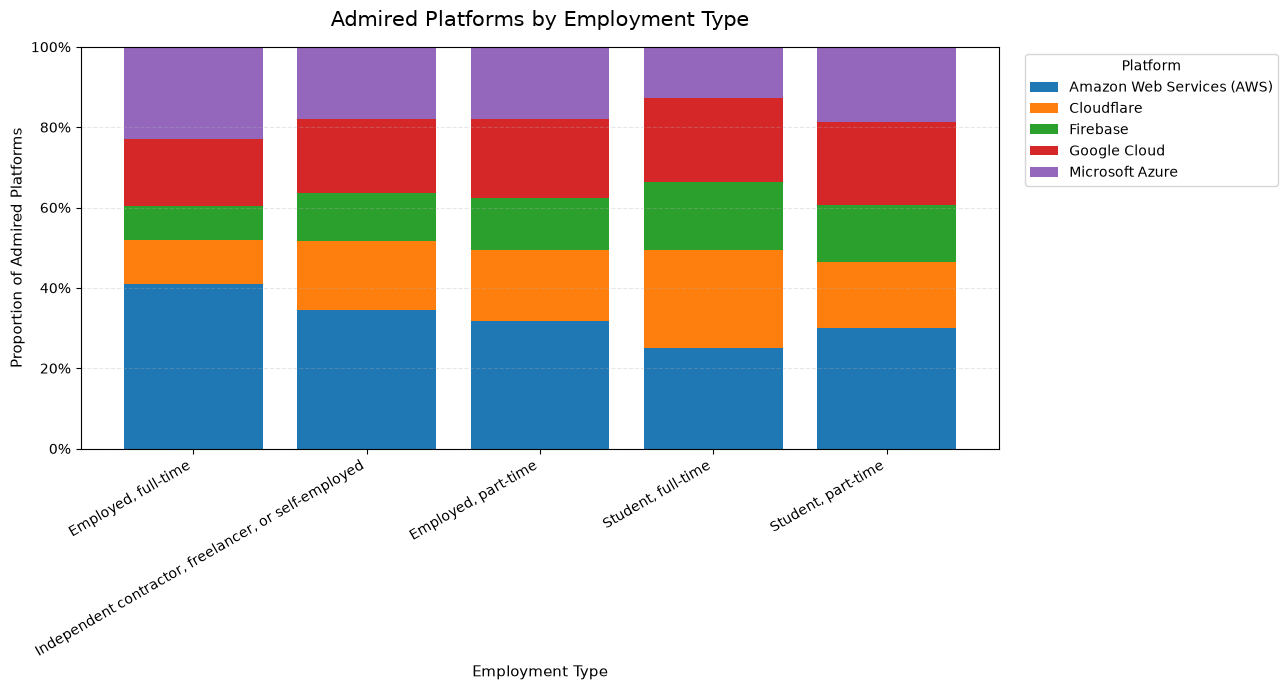

In [53]:
fig, ax = plt.subplots(figsize=(13, 7))

employment_platform_proportions.plot(
    kind="bar",
    stacked=True,
    width=0.8,
    ax=ax
)

ax.set_title(
    "Admired Platforms by Employment Type",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Employment Type", fontsize=11)
ax.set_ylabel("Proportion of Admired Platforms", fontsize=11)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.set_ylim(0, 1)

ax.legend(
    title="Platform",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
